In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("../data/customer_data.csv")

In [4]:
import os

os.listdir("../data")

['customer_data.csv']

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [8]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [9]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [10]:
df.sample(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
33538,26529593,"Cosy room in Queens, 5 min walk to subway(R/M)",199524563,Bei,Queens,Rego Park,40.72738,-73.86273,Private room,65,2,21,2019-05-28,1.76,3,0
17023,13523692,RARE NYC LOFT in Perfect Location,16836897,Hudson,Manhattan,Lower East Side,40.71827,-73.98983,Entire home/apt,180,4,13,2017-10-23,0.35,1,0
7254,5316908,Beautiful 1BD/ NEW RENOVATIONS/ELEV,1475015,Mike,Manhattan,Upper West Side,40.76917,-73.98488,Entire home/apt,87,30,7,2018-12-23,0.18,52,365
32859,25889683,Riverside Apartment Room,28996758,俞,Manhattan,Upper West Side,40.79811,-73.97186,Private room,72,1,5,2018-07-08,0.38,1,0
3355,2012104,"Spacious haven near Riverside park, subway, an...",10352213,Nicole,Manhattan,Morningside Heights,40.81615,-73.96156,Private room,55,2,19,2018-01-08,0.79,2,0


In [11]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

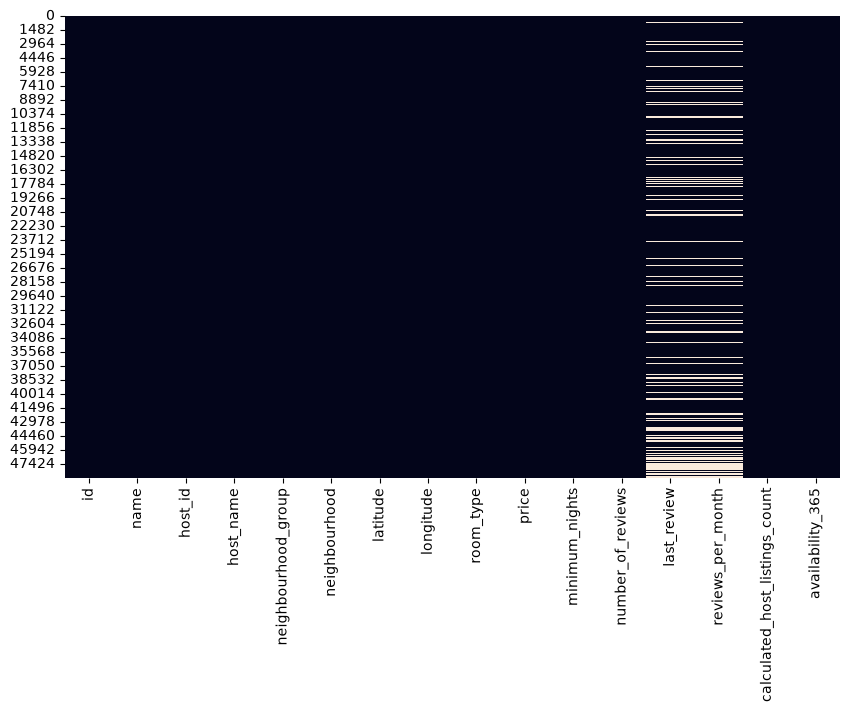

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [15]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [16]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [17]:
df['name'] = df['name'].fillna('Unknown')

In [18]:
df['host_name'] = df['host_name'].fillna('Unknown')

In [19]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [20]:
df['last_review'] = df['last_review'].fillna(pd.Timestamp('1900-01-01'))

In [21]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [22]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.shape

(48895, 16)

In [29]:
text_cols = ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']

for col in text_cols:
    df[col] = df[col].str.strip()

In [30]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1900-01-01,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [31]:
df.dtypes

id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                                    str
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [32]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

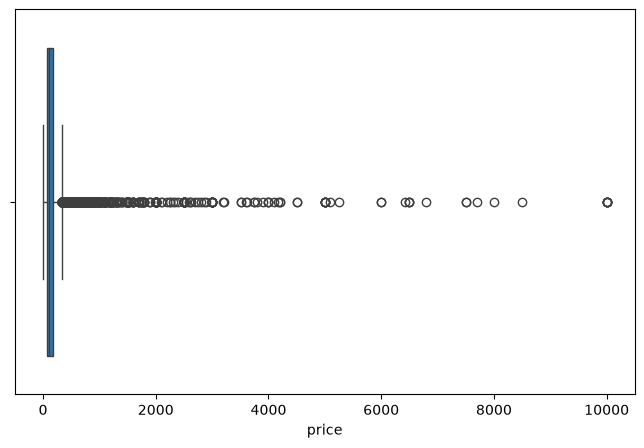

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.show()

In [34]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -90.0
Upper Bound: 334.0


In [35]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print("Outliers:", outliers.shape[0])

Outliers: 2972


In [36]:
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

In [37]:
df.shape

(45923, 16)

In [38]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              45923 non-null  int64         
 1   name                            45923 non-null  str           
 2   host_id                         45923 non-null  int64         
 3   host_name                       45923 non-null  str           
 4   neighbourhood_group             45923 non-null  str           
 5   neighbourhood                   45923 non-null  str           
 6   latitude                        45923 non-null  float64       
 7   longitude                       45923 non-null  float64       
 8   room_type                       45923 non-null  str           
 9   price                           45923 non-null  int64         
 10  minimum_nights                  45923 non-null  int64         
 11  number_of_reviews 

In [41]:
df.to_csv('../outputs/cleaned_customer_data.csv', index=False)

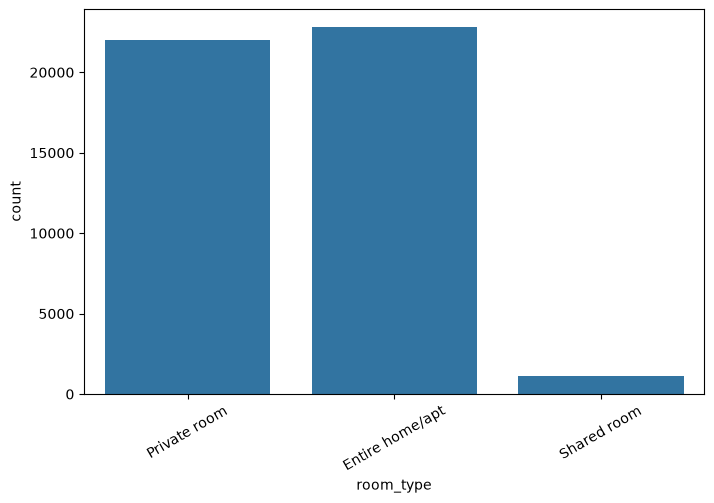

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='room_type')
plt.xticks(rotation=30)
plt.show()

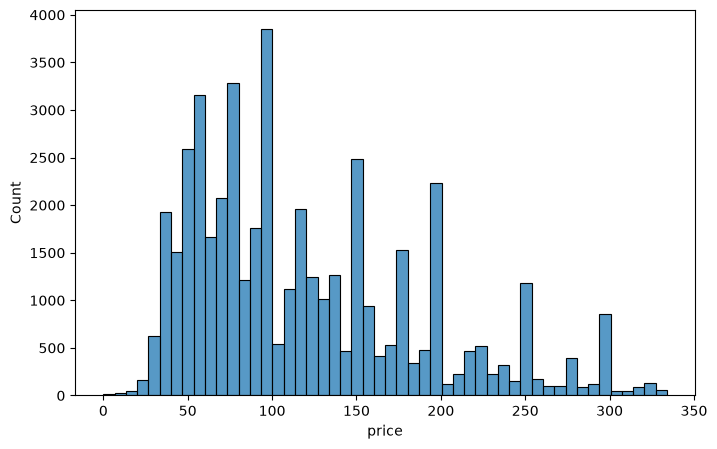

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.show()

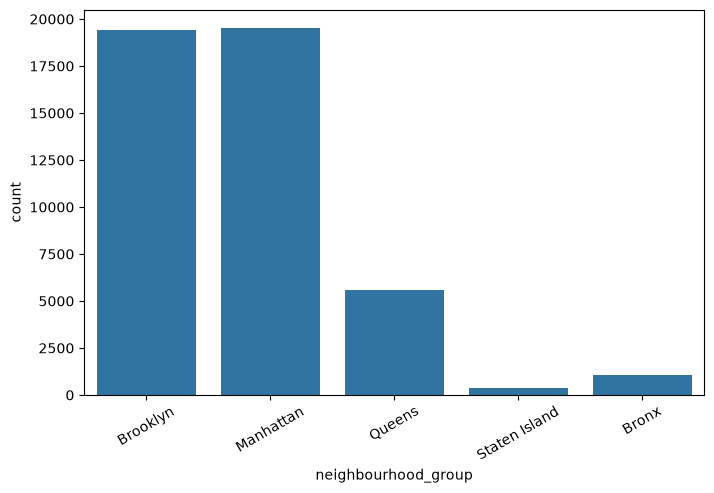

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood_group')
plt.xticks(rotation=30)
plt.show()

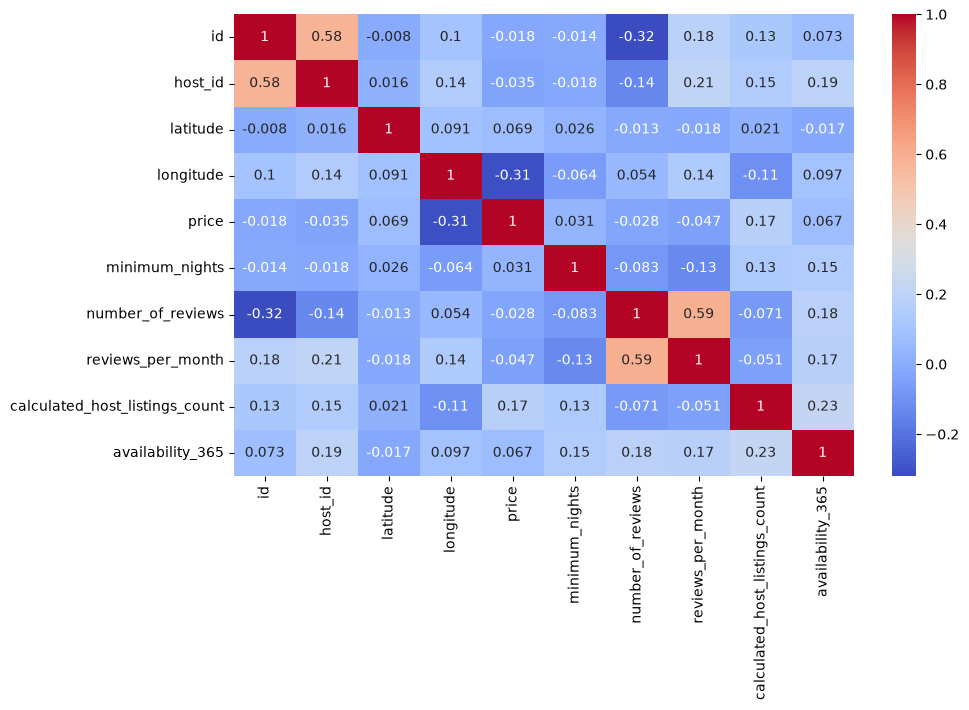

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

# Conclusion

Successfully cleaned and preprocessed the Airbnb NYC dataset.

## Cleaning Tasks Performed

- Handled missing values
- Converted date columns
- Standardized text data
- Checked for duplicate records
- Detected and removed outliers using IQR
- Performed exploratory data analysis

## Result

The dataset is now suitable for:
- Data Analysis
- Business Intelligence
- Machine Learning
- Predictive Modeling

In [46]:
import os

os.makedirs("../outputs", exist_ok=True)

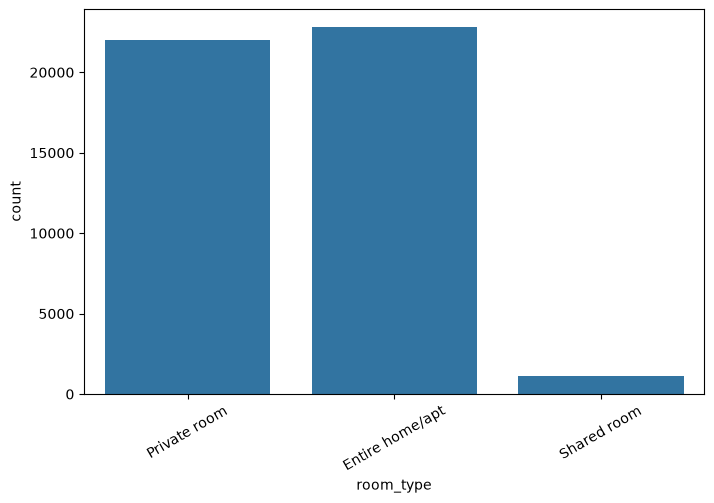

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='room_type')
plt.xticks(rotation=30)

plt.savefig('../outputs/room_type_distribution.png',
            bbox_inches='tight')

plt.show()

In [48]:
import os

os.listdir("../outputs")

['cleaned_customer_data.csv', 'room_type_distribution.png']

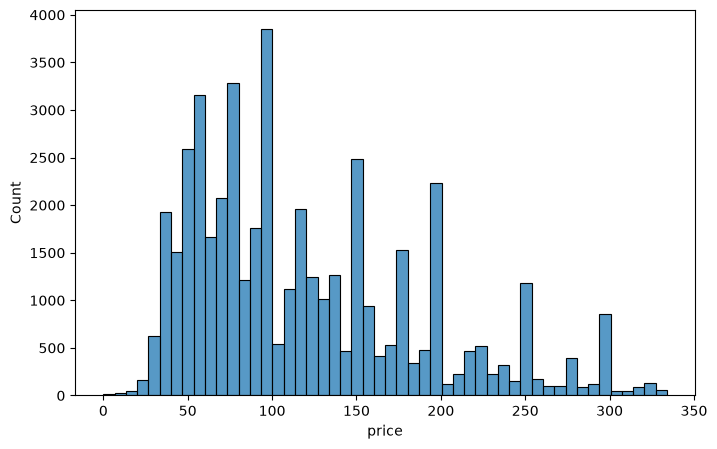

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)

plt.savefig('../outputs/price_distribution.png',
            bbox_inches='tight')

plt.show()

In [50]:
os.listdir("../outputs")

['cleaned_customer_data.csv',
 'price_distribution.png',
 'room_type_distribution.png']

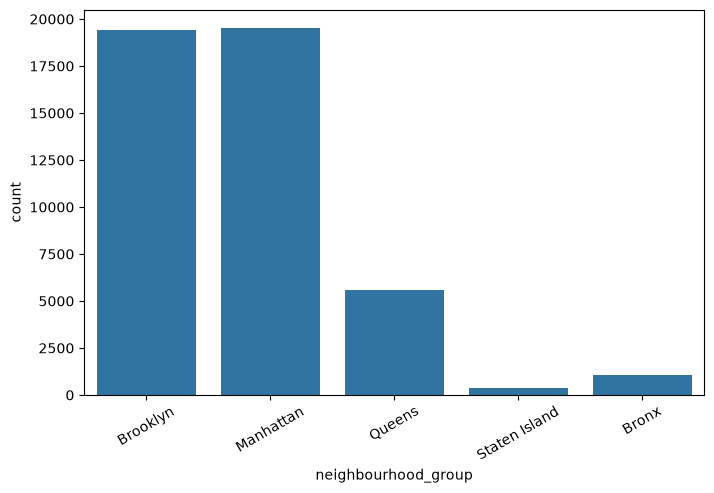

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood_group')

plt.xticks(rotation=30)

plt.savefig('../outputs/neighbourhood_group_distribution.png',
            bbox_inches='tight')

plt.show()

In [52]:
os.listdir("../outputs")

['cleaned_customer_data.csv',
 'neighbourhood_group_distribution.png',
 'price_distribution.png',
 'room_type_distribution.png']

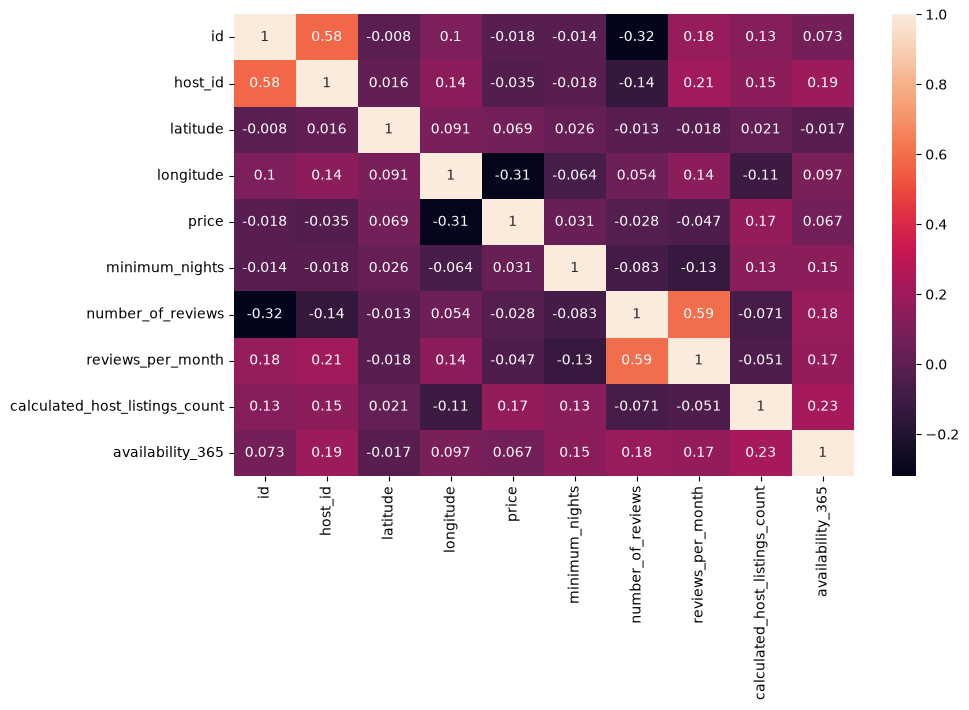

In [53]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True
)

plt.savefig('../outputs/correlation_heatmap.png',
            bbox_inches='tight')

plt.show()

In [54]:
os.listdir("../outputs")

['cleaned_customer_data.csv',
 'correlation_heatmap.png',
 'neighbourhood_group_distribution.png',
 'price_distribution.png',
 'room_type_distribution.png']

In [55]:
df.to_csv('../outputs/cleaned_customer_data.csv',
          index=False)

In [56]:
os.listdir("../outputs")

['cleaned_customer_data.csv',
 'correlation_heatmap.png',
 'neighbourhood_group_distribution.png',
 'price_distribution.png',
 'room_type_distribution.png']